In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

In [334]:
DATA_PATH = 'data/loan_data.csv'
RANDOM_SEED = 42

In [335]:
df = pd.read_csv(DATA_PATH)
df.shape

(381, 13)

### Data Cleaning

In [336]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [337]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          381 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 51.9 KB


Let's apply a consistent style to column names

In [338]:
df = df.rename(columns=lambda x: x.replace('_', ''))
df.columns

Index(['LoanID', 'Gender', 'Married', 'Dependents', 'Education',
       'SelfEmployed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'LoanAmountTerm', 'CreditHistory', 'PropertyArea', 'LoanStatus'],
      dtype='str')

In [339]:
df.isna().sum()

LoanID                0
Gender                5
Married               0
Dependents            8
Education             0
SelfEmployed         21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
LoanAmountTerm       11
CreditHistory        30
PropertyArea          0
LoanStatus            0
dtype: int64

In [340]:
df['Gender'].unique()

<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [341]:
df['CreditHistory'].unique()

array([ 1., nan,  0.])

We cannot recover NaN values, so let's drop them

In [342]:
df.dropna(inplace=True)
df.isna().sum()

LoanID               0
Gender               0
Married              0
Dependents           0
Education            0
SelfEmployed         0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
LoanAmountTerm       0
CreditHistory        0
PropertyArea         0
LoanStatus           0
dtype: int64

In [343]:
df.duplicated().sum()

np.int64(0)

### Data Analysis

In [344]:
df.columns

Index(['LoanID', 'Gender', 'Married', 'Dependents', 'Education',
       'SelfEmployed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'LoanAmountTerm', 'CreditHistory', 'PropertyArea', 'LoanStatus'],
      dtype='str')

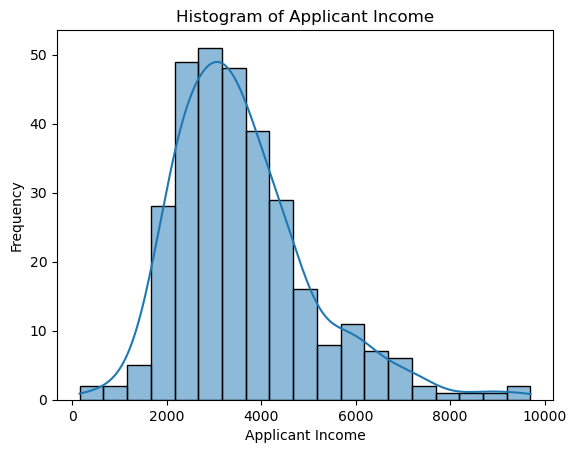

In [345]:
sns.histplot(data=df['ApplicantIncome'], kde=True)
plt.title('Histogram of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

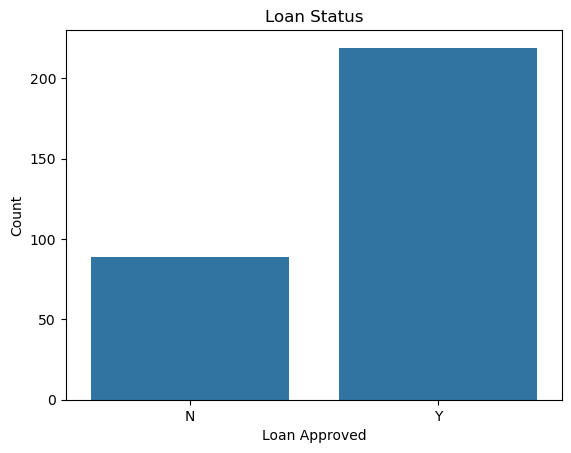

In [346]:
sns.countplot(x='LoanStatus', data=df)
plt.title('Loan Status')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

In [347]:
avg_loan_amount_by_education = df.groupby('Education')['LoanAmount'].mean().reset_index()
avg_loan_amount_by_education

,Education,LoanAmount
0,Graduate,105.344978
1,Not Graduate,102.531646


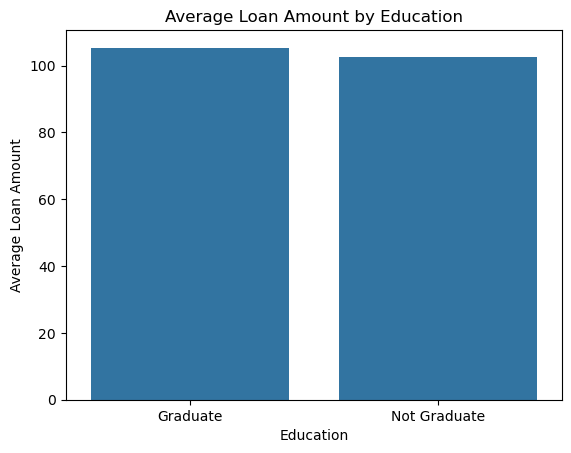

In [348]:
sns.barplot(x='Education', y='LoanAmount', data=avg_loan_amount_by_education)
plt.title('Average Loan Amount by Education')
plt.xlabel('Education')
plt.ylabel('Average Loan Amount')
plt.show()

Text(0.5, 1.0, 'Loan Amount distribution by Property Area')

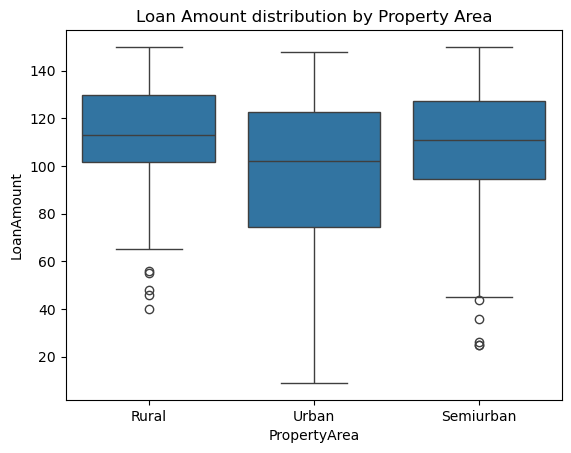

In [349]:
sns.boxplot(x='PropertyArea', y='LoanAmount', data=df)
plt.title('Loan Amount distribution by Property Area')

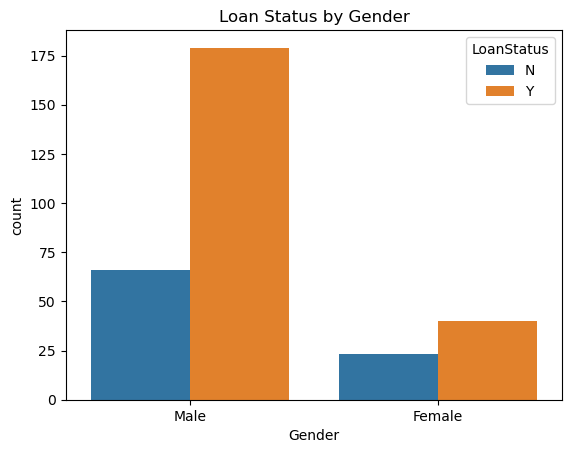

In [350]:
sns.countplot(x='Gender', hue='LoanStatus', data=df)
plt.title('Loan Status by Gender')
plt.show()

There is more males in the dataset.

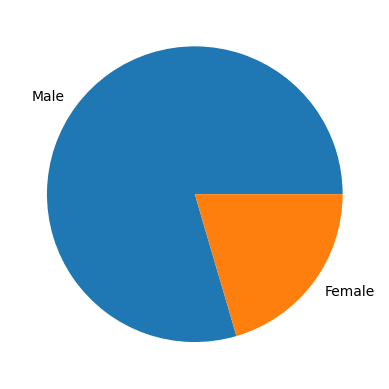

In [351]:
df['Gender'].value_counts().plot(kind='pie')
plt.show()

In [352]:
loan_status_by_married = df.groupby('Married')['LoanStatus'].value_counts().unstack()
loan_status_by_married

LoanStatus,N,Y
Married,,
No,44,79
Yes,45,140


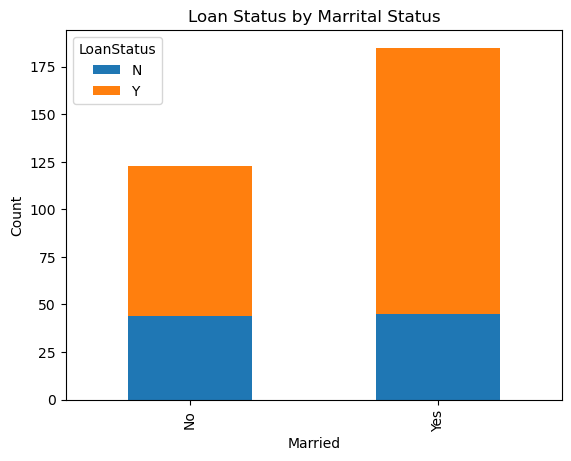

In [353]:
loan_status_by_married.plot(kind='bar', stacked=True)
plt.title('Loan Status by Marrital Status')
plt.ylabel('Count')
plt.show()

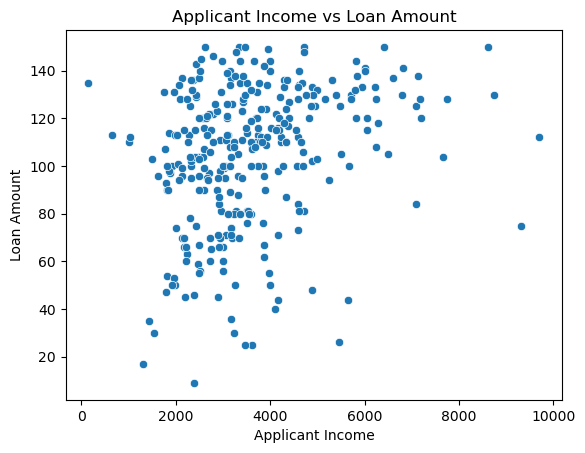

In [354]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

In [355]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory
0,4583,1508.0,128.0,360.0,1.0
1,3000,0.0,66.0,360.0,1.0
2,2583,2358.0,120.0,360.0,1.0
3,6000,0.0,141.0,360.0,1.0
4,2333,1516.0,95.0,360.0,1.0
...,...,...,...,...,...
376,5703,0.0,128.0,360.0,1.0
377,3232,1950.0,108.0,360.0,1.0
378,2900,0.0,71.0,360.0,1.0
379,4106,0.0,40.0,180.0,1.0


In [356]:
corr_matrix = numeric_df.corr()
corr_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory
ApplicantIncome,1.000000,-0.243677,0.267628,-0.099571,0.030307
CoapplicantIncome,-0.243677,1.000000,0.123028,-0.004158,0.012715
LoanAmount,0.267628,0.123028,1.000000,0.135069,-0.043853
LoanAmountTerm,-0.099571,-0.004158,0.135069,1.000000,0.015269
CreditHistory,0.030307,0.012715,-0.043853,0.015269,1.000000


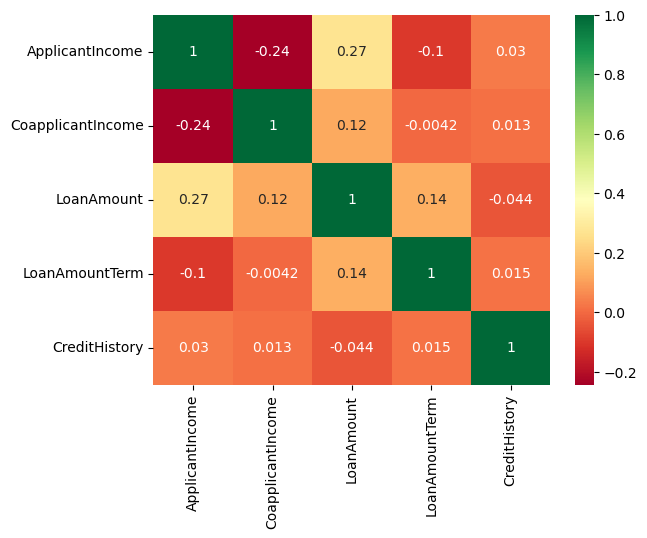

In [357]:
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn')
plt.show()

In [358]:
avg_loan_term_by_employed = df.groupby('SelfEmployed')['LoanAmountTerm'].mean()
avg_loan_term_by_employed

SelfEmployed
No     342.3
Yes    330.0
Name: LoanAmountTerm, dtype: float64

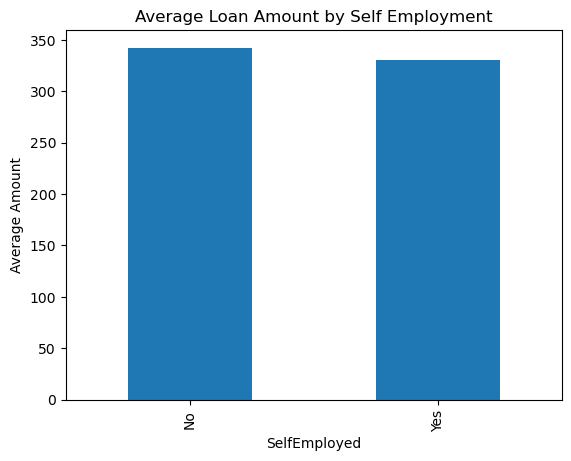

In [359]:
avg_loan_term_by_employed.plot(kind='bar')
plt.title('Average Loan Amount by Self Employment')
plt.ylabel('Average Amount')
plt.show()

### Feature Engineering

In [360]:
df

,LoanID,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [361]:
X = df[['Married', 'ApplicantIncome', 'LoanAmount', 'Education', 'CreditHistory']]
X

,Married,ApplicantIncome,LoanAmount,Education,CreditHistory
0,Yes,4583,128.0,Graduate,1.0
1,Yes,3000,66.0,Graduate,1.0
2,Yes,2583,120.0,Not Graduate,1.0
3,No,6000,141.0,Graduate,1.0
4,Yes,2333,95.0,Not Graduate,1.0
...,...,...,...,...,...
376,Yes,5703,128.0,Graduate,1.0
377,Yes,3232,108.0,Graduate,1.0
378,No,2900,71.0,Graduate,1.0
379,Yes,4106,40.0,Graduate,1.0


In [362]:
y = df[['LoanStatus']]
y

,LoanStatus
0,N
1,Y
2,Y
3,Y
4,Y
...,...
376,Y
377,Y
378,Y
379,Y


In [363]:
y['LoanStatus'] = y['LoanStatus'].replace({'Y': 1, 'N': 0}).astype(int)
y.dtypes

LoanStatus    int64
dtype: object

In [364]:
X['Married'] = X['Married'].replace({'Yes': 1, 'No': 0})
X

,Married,ApplicantIncome,LoanAmount,Education,CreditHistory
0,1,4583,128.0,Graduate,1.0
1,1,3000,66.0,Graduate,1.0
2,1,2583,120.0,Not Graduate,1.0
3,0,6000,141.0,Graduate,1.0
4,1,2333,95.0,Not Graduate,1.0
...,...,...,...,...,...
376,1,5703,128.0,Graduate,1.0
377,1,3232,108.0,Graduate,1.0
378,0,2900,71.0,Graduate,1.0
379,1,4106,40.0,Graduate,1.0


In [365]:
X['Education'] = X['Education'].replace({'Graduate': 1, 'Not Graduate': 0})
X

,Married,ApplicantIncome,LoanAmount,Education,CreditHistory
0,1,4583,128.0,1,1.0
1,1,3000,66.0,1,1.0
2,1,2583,120.0,0,1.0
3,0,6000,141.0,1,1.0
4,1,2333,95.0,0,1.0
...,...,...,...,...,...
376,1,5703,128.0,1,1.0
377,1,3232,108.0,1,1.0
378,0,2900,71.0,1,1.0
379,1,4106,40.0,1,1.0


In [366]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
y_train.dtypes

LoanStatus    int64
dtype: object

In [367]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[ 0.80684987, -0.52540099,  0.59660096,  0.58047956,  0.39361095],
       [ 0.80684987, -2.40162529,  1.02469188,  0.58047956,  0.39361095],
       [ 0.80684987, -1.07412105,  0.77497218,  0.58047956,  0.39361095],
       ...,
       [ 0.80684987,  1.41194483,  0.84632066, -1.72271354,  0.39361095],
       [-1.23938794,  2.15364405,  0.84632066, -1.72271354,  0.39361095],
       [-1.23938794,  0.22522609, -1.82924757, -1.72271354,  0.39361095]],
      shape=(246, 5))

### Logistic Regression Classifier

In [373]:
logistic = LogisticRegression()
logistic.fit(X_train, y_train.iloc[:, 0])

logistic_preds = logistic.predict(X_test)
print(classification_report(y_test.iloc[:, 0], logistic_preds))

              precision    recall  f1-score   support

           0       0.83      0.50      0.62        20
           1       0.80      0.95      0.87        42

    accuracy                           0.81        62
   macro avg       0.82      0.73      0.75        62
weighted avg       0.81      0.81      0.79        62



### KNNeighbors Classifier

In [369]:
knn_params = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}

knn = GridSearchCV(KNeighborsClassifier(), knn_params)
knn.fit(X_train, y_train.iloc[:, 0])

knn_preds = knn.predict(X_test)
print(classification_report(y_test.iloc[:, 0], knn_preds))

              precision    recall  f1-score   support

           0       0.77      0.50      0.61        20
           1       0.80      0.93      0.86        42

    accuracy                           0.79        62
   macro avg       0.78      0.71      0.73        62
weighted avg       0.79      0.79      0.78        62



### SVM Classifier

In [377]:
svc_params = {'C': [0.007, 0.01, 0.1, 0.5], 'kernel': ['linear', 'lbf', 'poly']}

svc = GridSearchCV(SVC(), svc_params)
svc.fit(X_train, y_train)

svc_preds = svc.predict(X_test)
print(classification_report(y_test, svc_preds))
svc.best_params_

              precision    recall  f1-score   support

           0       0.83      0.50      0.62        20
           1       0.80      0.95      0.87        42

    accuracy                           0.81        62
   macro avg       0.82      0.73      0.75        62
weighted avg       0.81      0.81      0.79        62



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

{'C': 0.007, 'kernel': 'linear'}

## Pipeline export